In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/Walmart_cleaned.csv")

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Quarter,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February,1,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February,1,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February,1,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February,1,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March,1,9


## Which stores are the strongest and weakest performers?

In [4]:
# Which stores generate the highest and lowest avg weekly sales
store_performance=(
    df.groupby("Store")["Weekly_Sales"]
    .agg(["sum","mean"])
    .reset_index()
)

In [5]:
store_performance.head()

,Store,sum,mean
0,1,2.224028e+08,1.555264e+06
1,2,2.753824e+08,1.925751e+06
2,3,5.758674e+07,4.027044e+05
3,4,2.995440e+08,2.094713e+06
4,5,4.547569e+07,3.180118e+05


In [6]:
store_performance.columns=[
    "Store","Total_Sales","Average_Weekly_Sales"
]

In [7]:
store_performance.head()

,Store,Total_Sales,Average_Weekly_Sales
0,1,2.224028e+08,1.555264e+06
1,2,2.753824e+08,1.925751e+06
2,3,5.758674e+07,4.027044e+05
3,4,2.995440e+08,2.094713e+06
4,5,4.547569e+07,3.180118e+05


In [8]:
top_stores=store_performance.sort_values(
    "Average_Weekly_Sales",ascending=False
).head(10)

In [9]:
bottom_stores=store_performance.sort_values(
    "Average_Weekly_Sales"
).head(10)

In [10]:
top_stores

,Store,Total_Sales,Average_Weekly_Sales
19,20,3.013978e+08,2.107677e+06
3,4,2.995440e+08,2.094713e+06
13,14,2.889999e+08,2.020978e+06
12,13,2.865177e+08,2.003620e+06
1,2,2.753824e+08,1.925751e+06
9,10,2.716177e+08,1.899425e+06
26,27,2.538559e+08,1.775216e+06
5,6,2.237561e+08,1.564728e+06
0,1,2.224028e+08,1.555264e+06
38,39,2.074455e+08,1.450668e+06


In [11]:
bottom_stores

,Store,Total_Sales,Average_Weekly_Sales
32,33,37160221.96,259861.692028
43,44,43293087.84,302748.866014
4,5,45475688.90,318011.810490
35,36,53412214.97,373511.992797
37,38,55159626.42,385731.653287
2,3,57586735.07,402704.441049
29,30,62716885.12,438579.616224
36,37,74202740.32,518900.281958
15,16,74252425.40,519247.730070
28,29,77141554.31,539451.428741


## Which stores have high sales but high volatility?

A store could have:

High sales + stable
High sales + unstable
Low sales + stable
Low sales + unstable

Management might particularly want to investigate:

High sales + high volatility

because demand may be harder to predict.

In [12]:
store_analysis=(
    df.groupby("Store")["Weekly_Sales"]
    .agg(["mean","std"])
    .reset_index()
)

In [14]:
store_analysis.head()

,Store,mean,std
0,1,1.555264e+06,155980.767761
1,2,1.925751e+06,237683.694682
2,3,4.027044e+05,46319.631557
3,4,2.094713e+06,266201.442297
4,5,3.180118e+05,37737.965745


In [15]:
store_analysis.columns=[
    "Store","Average_Weekly_Sales","Sales_Std"
]

In [16]:
store_analysis.head()

,Store,Average_Weekly_Sales,Sales_Std
0,1,1.555264e+06,155980.767761
1,2,1.925751e+06,237683.694682
2,3,4.027044e+05,46319.631557
3,4,2.094713e+06,266201.442297
4,5,3.180118e+05,37737.965745


In [17]:
store_analysis["CV"]=(
    store_analysis["Sales_Std"]/store_analysis["Average_Weekly_Sales"]
)

In [18]:
store_analysis.head()

,Store,Average_Weekly_Sales,Sales_Std,CV
0,1,1.555264e+06,155980.767761,0.100292
1,2,1.925751e+06,237683.694682,0.123424
2,3,4.027044e+05,46319.631557,0.115021
3,4,2.094713e+06,266201.442297,0.127083
4,5,3.180118e+05,37737.965745,0.118668


In [19]:
high_sales_threshold=(
    store_analysis["Average_Weekly_Sales"].median()
)

In [20]:
high_volatility_threshold=(
    store_analysis["CV"].median()
)

In [21]:
high_sales_threshold

966781.5594405595

In [22]:
high_volatility_threshold

0.13090268561738494

In [23]:
high_sales_high_volatility=(
    store_analysis[
        (store_analysis["Average_Weekly_Sales"]>high_sales_threshold)&
        (store_analysis["CV"]>high_volatility_threshold)
    ]
)

In [24]:
high_sales_high_volatility=high_sales_high_volatility.sort_values(
    "CV",ascending=False
)

In [25]:
high_sales_high_volatility

,Store,Average_Weekly_Sales,Sales_Std,CV
22,23,1.389864e+06,249788.038068,0.179721
17,18,1.084718e+06,176641.510839,0.162845
9,10,1.899425e+06,302262.062504,0.159133
13,14,2.020978e+06,317569.949476,0.157137
21,22,1.028501e+06,161251.350631,0.156783
38,39,1.450668e+06,217466.454833,0.149908
40,41,1.268125e+06,187907.162766,0.148177
11,12,1.009002e+06,139166.871880,0.137925
27,28,1.323522e+06,181758.967539,0.137330
5,6,1.564728e+06,212525.855862,0.135823


## Which stores benefit most from holiday periods?

In [26]:
holiday_analysis=(
    df.groupby(["Store","Holiday_Flag"])["Weekly_Sales"]
    .mean()
    .reset_index()
)

In [27]:
holiday_pivot=holiday_analysis.pivot(
    index="Store",
    columns="Holiday_Flag",
    values="Weekly_Sales"
)

In [28]:
holiday_pivot

Holiday_Flag,0,1
Store,,
1,1.546957e+06,1665747.656
2,1.914209e+06,2079266.900
3,4.000648e+05,437811.050
4,2.083556e+06,2243102.624
5,3.148923e+05,359501.607
6,1.555993e+06,1680907.927
7,5.629645e+05,672400.265
8,9.037434e+05,975330.860
9,5.405993e+05,588950.821


In [30]:
holiday_pivot.columns=[
    "Non_Holiday_Avg","Holiday_Avg"
]

In [32]:
holiday_pivot.head()

,Non_Holiday_Avg,Holiday_Avg
Store,,
1,1.546957e+06,1665747.656
2,1.914209e+06,2079266.900
3,4.000648e+05,437811.050
4,2.083556e+06,2243102.624
5,3.148923e+05,359501.607


In [33]:
holiday_pivot["Holiday_Uplift_%"]=(
    (holiday_pivot["Holiday_Avg"]-holiday_pivot["Non_Holiday_Avg"])/holiday_pivot["Non_Holiday_Avg"]
)*100

In [34]:
holiday_pivot.head()

,Non_Holiday_Avg,Holiday_Avg,Holiday_Uplift_%
Store,,,
1,1.546957e+06,1665747.656,7.678962
2,1.914209e+06,2079266.900,8.622784
3,4.000648e+05,437811.050,9.435021
4,2.083556e+06,2243102.624,7.657428
5,3.148923e+05,359501.607,14.166537


In [36]:
holiday_ranking=holiday_pivot.sort_values("Holiday_Uplift_%",ascending=False)

In [37]:
holiday_ranking.head()

,Non_Holiday_Avg,Holiday_Avg,Holiday_Uplift_%
Store,,,
7,562964.454812,672400.265,19.439204
35,908099.154211,1074348.457,18.307395
15,617064.840150,706406.018,14.478410
5,314892.276917,359501.607,14.166537
12,999291.924436,1138140.420,13.894688


Business use

Stores with high holiday uplift may deserve:

additional inventory
staffing preparation
promotional planning
increased demand monitoring

In [38]:
# find the lowest
holiday_ranking.tail()

,Non_Holiday_Avg,Holiday_Avg,Holiday_Uplift_%
Store,,,
30,438708.962782,436859.307,-0.421613
38,386049.080000,381509.878,-1.175810
36,373953.448647,367640.630,-1.688130
37,519755.562556,507525.050,-2.353128
44,303253.622782,296035.601,-2.380193


## Which months represent the strongest sales opportunity?

In [39]:
monthly_sales=(
    df.groupby("Month")["Weekly_Sales"]
    .mean()
    .reset_index()
)

In [40]:
monthly_sales.head()

,Month,Weekly_Sales
0,1,9.238846e+05
1,2,1.053200e+06
2,3,1.013309e+06
3,4,1.026762e+06
4,5,1.031714e+06


In [41]:
monthly_sales=monthly_sales.sort_values(
    "Weekly_Sales",ascending=False
)

In [42]:
monthly_sales.head()

,Month,Weekly_Sales
11,12,1.281864e+06
10,11,1.147266e+06
5,6,1.064325e+06
1,2,1.053200e+06
7,8,1.048017e+06


Business interpretation

The dataset shows a strong year-end sales pattern, particularly in November and December.

Potential business actions:

Walmart could prepare inventory, staffing and promotional activity ahead of the year-end period.

## How does sales performance differ between years?

In [43]:
yearly_sales=(
    df.groupby("Year")["Weekly_Sales"].mean().reset_index()
)

In [45]:
yearly_sales.head()

,Year,Weekly_Sales
0,2010,1.059670e+06
1,2011,1.046239e+06
2,2012,1.033660e+06


In [46]:
yearly_sales.columns=["Year","Average_Weekly_Sales"]

In [47]:
yearly_sales.head()

,Year,Average_Weekly_Sales
0,2010,1.059670e+06
1,2011,1.046239e+06
2,2012,1.033660e+06


In [48]:
yearly_sales["YoY_Change_%"]=(
    yearly_sales["Average_Weekly_Sales"].pct_change()*100
)

Why .pct_change()?  
Suppose:  
2010 = 1,000,000  
2011 = 1,100,000  
Then:  
((1,100,000 - 1,000,000)/1,000,000)× 100
= 10%  
So sales increased by 10%.  

In [49]:
yearly_sales.head()

,Year,Average_Weekly_Sales,YoY_Change_%
0,2010,1.059670e+06,NaN
1,2011,1.046239e+06,-1.267393
2,2012,1.033660e+06,-1.202299


What is happening?

2010:
There is no previous year in your data, so YoY_Change_% is NaN. That's expected.

2011:
Average weekly sales decreased by 1.27% compared with 2010.

2012:
Average weekly sales decreased by another 1.20% compared with 2011.

So your dataset shows a gradual decline in average weekly sales from 2010 → 2012.

Don't say:

"Walmart sales declined by 1.27% in 2011 and 1.20% in 2012."

A better statement is:

"Average weekly sales declined by approximately 1.27% in 2011 and a further 1.20% in 2012, indicating a gradual downward trend across the observed period."

## Which stores contribute the most to Walmart's total sales?

In [50]:
# What percentage of total sales come from each store?
store_contribution=(
    df.groupby("Store")["Weekly_Sales"].sum().reset_index()
)

In [51]:
store_contribution.head()

,Store,Weekly_Sales
0,1,2.224028e+08
1,2,2.753824e+08
2,3,5.758674e+07
3,4,2.995440e+08
4,5,4.547569e+07


In [54]:
store_contribution.columns=["Store","Total_Sales"]

In [55]:
store_contribution.head()

,Store,Total_Sales
0,1,2.224028e+08
1,2,2.753824e+08
2,3,5.758674e+07
3,4,2.995440e+08
4,5,4.547569e+07


In [56]:
total_sales=store_contribution["Total_Sales"].sum()

In [57]:
store_contribution["Sales_Contribution_%"]=(
    store_contribution["Total_Sales"]/total_sales
)*100

In [58]:
store_contribution.head()

,Store,Total_Sales,Sales_Contribution_%
0,1,2.224028e+08,3.301107
1,2,2.753824e+08,4.087479
2,3,5.758674e+07,0.854755
3,4,2.995440e+08,4.446107
4,5,4.547569e+07,0.674992


In [59]:
store_contribution=store_contribution.sort_values("Total_Sales",ascending=False)

In [60]:
store_contribution.head()

,Store,Total_Sales,Sales_Contribution_%
19,20,3.013978e+08,4.473623
3,4,2.995440e+08,4.446107
13,14,2.889999e+08,4.289602
12,13,2.865177e+08,4.252759
1,2,2.753824e+08,4.087479


## Which stores need attention?

In [61]:
# Step-1 Calculte median thresholds
sales_median=store_analysis["Average_Weekly_Sales"].median()
cv_median=store_analysis["CV"].median()

In [62]:
# Step-2 Classify Stores
def classify_store(row):
    high_sales=row["Average_Weekly_Sales"]>=sales_median
    low_volatility=row["CV"]<=cv_median
    if high_sales and low_volatility:
        return "High Performance-Stable"
    elif high_sales and not low_volatility:
        return "High Performance-Volatile"
    elif not high_sales and low_volatility:
        return "Lower Performance-Stable"
    else:
        return "Lower Performance-Volatile"

In [63]:
store_analysis["Category"]=store_analysis.apply(
    classify_store,axis=1
)

In [65]:
store_analysis.sort_values(
    "Average_Weekly_Sales",
    ascending=False
).head()

,Store,Average_Weekly_Sales,Sales_Std,CV,Category
19,20,2.107677e+06,275900.562742,0.130903,High Performance-Stable
3,4,2.094713e+06,266201.442297,0.127083,High Performance-Stable
13,14,2.020978e+06,317569.949476,0.157137,High Performance-Volatile
12,13,2.003620e+06,265506.995776,0.132514,High Performance-Volatile
1,2,1.925751e+06,237683.694682,0.123424,High Performance-Stable


| Category                         | Meaning                            |
| -------------------------------- | ---------------------------------- |
| **High Performance - Stable**    | High sales + relatively consistent |
| **High Performance - Volatile**  | High sales + fluctuating demand    |
| **Lower Performance - Stable**   | Lower sales + consistent           |
| **Lower Performance - Volatile** | Lower sales + fluctuating demand   |


## Summarize the business recommendations

**Store Performance**

* **Top Performer:** Store 20 leads overall performance with the highest average weekly sales.
* **Underperformer:** Store 33 ranks among the weakest-performing locations.
* **Action:** Analyze operational characteristics of high-performing stores to replicate successful practices, while investigating root causes behind underperforming locations.

---

**Volatility**

* **Highest Fluctuation:** Store 35 experiences the highest relative sales volatility, with a Coefficient of Variation (CV) of ~22.97%.
* **Action:** Implement tighter demand monitoring and dynamic inventory planning for high-volatility locations to prevent stockouts and overstock.

---

**Holiday Planning**

* **Holiday Uplift:** Store 7 demonstrates a ~19.4% increase in average weekly sales during holiday periods.
* **Action:** Allocate additional inventory, logistics support, and staffing to high-uplift stores ahead of peak holiday weeks.

---

**Seasonal Planning**

* **Peak vs. Trough:** December weekly sales average ~38.75% higher than January sales.
* **Action:** Align inventory procurement, staffing schedules, and promotional campaigns well ahead of the November–December surge.

---

**External Factors**

* **Correlation Insight:** Fuel price, temperature, CPI, and unemployment display very weak correlations with weekly sales.
* **Action:** Avoid relying on macroeconomic and weather metrics as primary sales predictors. Focus analytical efforts on internal drivers such as store attributes, seasonality, and promotional activity.

## Business-analysis charts

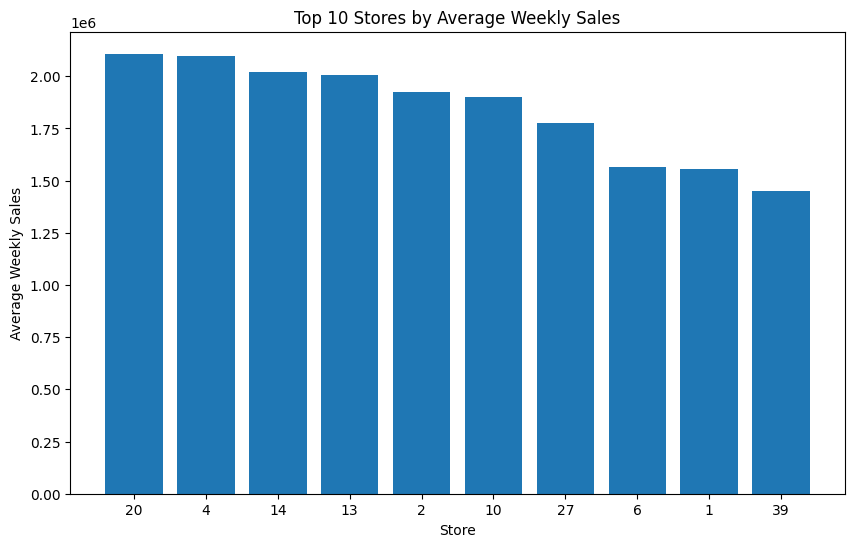

In [ ]:
# Top 10 Stores
top_10=store_analysis.sort_values(
    "Average_Weekly_Sales",
    ascending=False
).head(10)
plt.figure(figsize=(10, 6))
plt.bar(
    top_10["Store"].astype(str),
    top_10["Average_Weekly_Sales"]
)
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.title("Top 10 Stores by Average Weekly Sales")
plt.savefig("../images/business_analysis/top10_stores_by avg_weekly_sales.png")
plt.show()

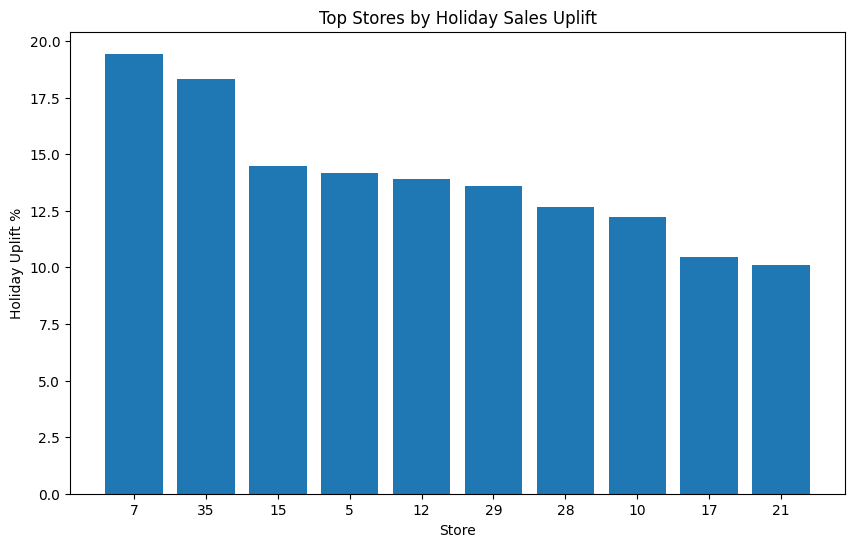

In [71]:
# Holiday uplift
top_holiday=holiday_ranking.head(10)
plt.figure(figsize=(10,6))
plt.bar(
    top_holiday.index.astype(str),
    top_holiday["Holiday_Uplift_%"]
)
plt.xlabel("Store")
plt.ylabel("Holiday Uplift %")
plt.title("Top Stores by Holiday Sales Uplift")
plt.savefig("../images/business_analysis/top_stores_by_holiday_sales_uplift.png")
plt.show()

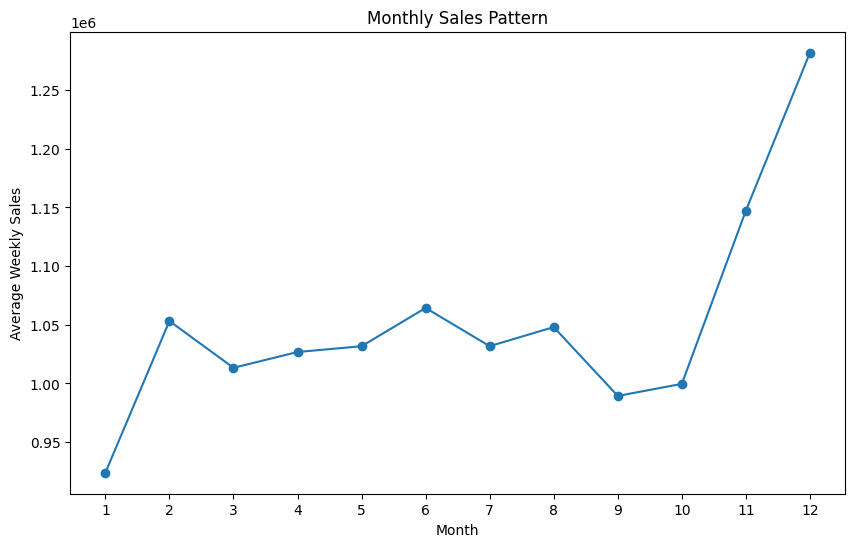

In [72]:
# Monthly Sales opportunity
monthly_chart=(
    df.groupby("Month")["Weekly_Sales"]
      .mean()
)
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_chart.index,
    monthly_chart.values,
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.title("Monthly Sales Pattern")
plt.xticks(range(1, 13))
plt.savefig("../images/business_analysis/monthly_sales_pattern.png")
plt.show()